## Importing data and analysing
(add description)

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import ExtraTreesRegressor

#load data from unified_environment_focus_dataset.csv
df = pd.read_csv('../../data/processed/unified_environment_focus_dataset.csv')

print(df.head(10))




              timestamp                        session_id location_id  \
0  2013-08-23T16:06:00Z  keti_1min_resampled__510__s00001         510   
1  2013-08-23T16:24:00Z  keti_1min_resampled__415__s00001         415   
2  2013-08-23T16:25:00Z  keti_1min_resampled__415__s00001         415   
3  2013-08-23T16:26:00Z  keti_1min_resampled__415__s00001         415   
4  2013-08-23T16:27:00Z  keti_1min_resampled__415__s00001         415   
5  2013-08-23T16:28:00Z  keti_1min_resampled__415__s00001         415   
6  2013-08-23T16:29:00Z  keti_1min_resampled__415__s00001         415   
7  2013-08-23T16:30:00Z  keti_1min_resampled__415__s00001         415   
8  2013-08-23T16:31:00Z  keti_1min_resampled__415__s00001         415   
9  2013-08-23T16:32:00Z  keti_1min_resampled__415__s00001         415   

                          record_id               source  humidity  light  \
0  keti_1min_resampled:row_00192329  keti_1min_resampled       NaN    NaN   
1  keti_1min_resampled:row_00011995  keti_

In [22]:
# count how many values are missing in each column and print the names of columns with missing values, including percantages
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values(by="missing_count", ascending=False).reset_index().rename(columns={"index": "column"})
display(missing_summary)

,column,missing_count,missing_pct
0,focus_score,973459,100.000000
1,noise,552867,56.794071
2,light,422194,43.370496
3,co2,23983,2.463689
4,temperature,1583,0.162616
5,humidity,1573,0.161589
6,timestamp,0,0.000000
7,location_id,0,0.000000
8,session_id,0,0.000000
9,record_id,0,0.000000


Because percentage of rows that are missing either, co2, temperature or humidity is less than 3% of the dataset we decided to remove those rows. It is also because later we want to find out different type of rooms where those 3 features are more or less correlated with each other, so it would not make sense to impute those 3% rows values due to redundancy and overcomplicating the solution.

In [23]:
# remove rows where either co2, temperature, or humidity are missing
df = df.dropna(subset=['co2', 'temperature', 'humidity'])

missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct}).sort_values(by="missing_count", ascending=False).reset_index().rename(columns={"index": "column"})
display(missing_summary)

,column,missing_count,missing_pct
0,focus_score,947898,100.000000
1,noise,527330,55.631513
2,light,420594,44.371230
3,location_id,0,0.000000
4,session_id,0,0.000000
5,timestamp,0,0.000000
6,record_id,0,0.000000
7,humidity,0,0.000000
8,source,0,0.000000
9,temperature,0,0.000000


## Imputing missing Light and Noise values
Run KMeans clustering algorithm to group data into room types based on 3 feature (temperature, humidity, CO2). Using elbow method to find reasonable number of clusters.

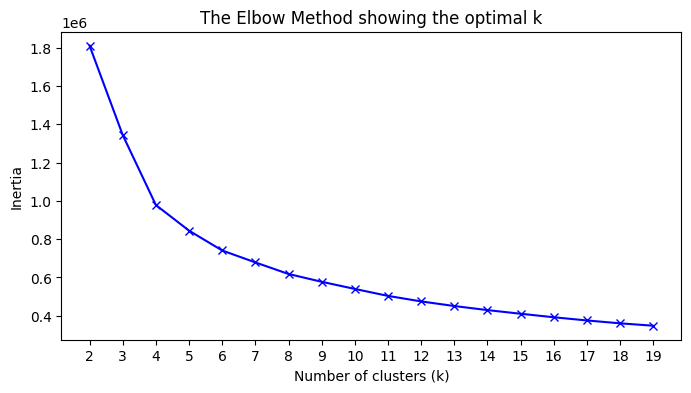

In [24]:
combined_df = df.copy()


# We use these 3 to group similar rows together
anchors = ['temperature', 'humidity', 'co2']

# Scale the data (Standardize) so CO2 doesn't drown out Temperature
scaled_data = StandardScaler().fit_transform(combined_df[anchors])


from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K = range(2, 20) # Test from 2 to 20 clusters

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_data) # Use your scaled anchor data
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xticks(K)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.show()



In [25]:
import plotly.express as px
import pandas as pd
from sklearn.cluster import KMeans

# --- 4. INTERACTIVE 3D VISUALIZATION (k=4) ---

# Define the choice
k_choice = 4
max_points = 15000 

# 1. Generate the clustering model specifically for k=4
km_final = KMeans(n_clusters=k_choice, random_state=42, n_init=10)
labels = km_final.fit_predict(scaled_data)

# 2. Create the full DataFrame first
# We ensure 'Cluster' is a standard column so Plotly can find it
full_plot_df = pd.DataFrame(scaled_data, columns=['Temp', 'Humidity', 'CO2'])
full_plot_df['Cluster'] = labels.astype(str)

# 3. Downsample: If we have more than our limit, take a random sample
if len(full_plot_df) > max_points:
    print(f"Sampling {max_points} points from {len(full_plot_df)} for performance...")
    plot_df = full_plot_df.sample(n=max_points, random_state=42)
else:
    plot_df = full_plot_df

# 4. Generate the interactive plot
fig = px.scatter_3d(
    plot_df, 
    x='Temp', 
    y='Humidity', 
    z='CO2',
    color='Cluster', # This matches the column name added above
    title=f'Interactive 3D Cluster Map (k={k_choice}) - Sampled Data',
    opacity=0.6, 
    template='plotly_dark' 
)

# Optimize the markers for performance
fig.update_traces(marker=dict(size=3)) 

fig.show()

Sampling 15000 points from 947898 for performance...


Using elbow method and analysing the 3d graph, 4 clusters were picked because that is where the improvement starts to level off (adding more clusters than 4 is not dropping inertia significantly enough), so adding more would just make the model more complex without actually helping much. 

## Impute Light and Noise
We utilized an IterativeImputer with an ExtraTreesRegressor backend. Unlike standard linear MICE, ExtraTrees captures non-linear interactions between variables (e.g., $CO_2$ spikes as a proxy for occupancy affecting light). For "dead" clusters, where `Light` or `Noise` are 100% missing, we applied a Global Median fallback. This is a deliberate design choice to handle extreme data sparsity, without at least some local ground truth, a model cannot statistically converge on a meaningful correlation, and a robust central tendency (median) is used to prevent model bias.

In [26]:
# This class modifies ExtraTreesRegressor by teaching the Forest how to calculate 
# uncertainty (std).
class SmartForest(ExtraTreesRegressor):
    def predict(self, X, return_std=False):
        if not return_std:
            return super().predict(X)
        # We ask every tree in the forest for its guess
        all_preds = np.stack([t.predict(X) for t in self.estimators_])
        # Return the average and the "disagreement" (standard deviation)
        return np.mean(all_preds, axis=0), np.std(all_preds, axis=0)

model_kmeans = KMeans(n_clusters=4, random_state=42)
combined_df['room_type'] = model_kmeans.fit_predict(scaled_data)

# Columns to use for imputation in the new dataset
impute_cols = ['co2', 'noise', 'temperature', 'light', 'humidity']
missing_impute_cols = [col for col in impute_cols if col not in combined_df.columns]
if missing_impute_cols:
    raise ValueError(f"Missing required columns for imputation: {missing_impute_cols}")

# --- 3. MOCKING LIGHT AND NOISE (STREAMLINED ROBUST LOOP) ---

imputed_chunks = []

# We go through every group found by KMeans
for room_id in sorted(combined_df['room_type'].unique()):
    print(f"Processing Cluster {room_id}...")
    
    # Get the rows for just this group
    chunk = combined_df[combined_df['room_type'] == room_id].copy()
    original_backup = chunk.copy()
    
    # Create the imputer
    mice = IterativeImputer(
        estimator=SmartForest(
            n_estimators=20, 
            max_depth=15, 
            min_samples_leaf=5, 
            random_state=42
        ),
        sample_posterior=True, 
        n_nearest_features=5,
        random_state=42
    )
    
    # 1. Limit to the columns we want to use for imputation
    numbers_only = [col for col in impute_cols if col in chunk.columns]
    
    # 2. Identify which sensors are active vs. 100% missing in this cluster
    active_cols = [col for col in numbers_only if chunk[col].notna().any()]
    dropped_cols = list(set(numbers_only) - set(active_cols))
    
    # Printout to see exactly what is happening in each cluster
    if dropped_cols:
        print(f"  ⚠️  Cluster {room_id}: Skipping sensor(s) {dropped_cols} (100% missing in this cluster)")
    else:
        print(f"  ✅  Cluster {room_id}: All sensors present. Running full smart imputation.")
    
    # 3. Run the Imputation
    # (No 'if' check needed here because Temp, Hum, and CO2 are pre-filled)
    filled_data = mice.fit_transform(chunk[active_cols])
    temp_df = pd.DataFrame(filled_data, columns=active_cols, index=chunk.index)
    
    # --- PROTECTION: RESTORE THE ORIGINAL DATA ---
    # We only want the imputed Light and Noise. Everything else stays pure.
    for col in active_cols:
        if col in ['temperature', 'humidity', 'co2']:
            temp_df[col] = original_backup[col].values
            
    # Re-add non-imputed columns and any skipped sensors
    for col in chunk.columns:
        if col not in temp_df.columns:
            temp_df[col] = original_backup[col].values
    
    imputed_chunks.append(temp_df)

# --- 4. FINAL GLUE AND SAFETY NET ---

# Combine all the groups and sort them back into the original order
final_df = pd.concat(imputed_chunks).sort_index()

# THE SAFETY NET: Fill any sensors that were 100% dead in a cluster with the global median
final_df['light'] = final_df['light'].fillna(combined_df['light'].median())
final_df['noise'] = final_df['noise'].fillna(combined_df['noise'].median())

# Apply the final column order for the new dataset
final_cols = [
    'timestamp',
    'session_id',
    'location_id',
    'record_id',
    'source',
    'humidity',
    'light',
    'temperature',
    'noise',
    'co2',
    'focus_score'
 ]
final_df = final_df[final_cols]

print("\n--- Final Imputation Complete ---")
print(f"Missing values remaining: {final_df[['light', 'noise']].isna().sum().sum()}")

# --- 5. VISUAL CHECK ---

print("\nTop of your new dataset:")
print(final_df.head())



Processing Cluster 0...
  ✅  Cluster 0: All sensors present. Running full smart imputation.
Processing Cluster 1...
  ✅  Cluster 1: All sensors present. Running full smart imputation.
Processing Cluster 2...
  ✅  Cluster 2: All sensors present. Running full smart imputation.
Processing Cluster 3...
  ✅  Cluster 3: All sensors present. Running full smart imputation.

--- Final Imputation Complete ---
Missing values remaining: 0

Top of your new dataset:
                timestamp                         session_id location_id  \
190  2013-08-23T23:04:00Z   keti_1min_resampled__510__s00001         510   
191  2013-08-23T23:04:00Z   keti_1min_resampled__511__s00001         511   
194  2013-08-23T23:04:00Z   keti_1min_resampled__558__s00001         558   
196  2013-08-23T23:04:00Z   keti_1min_resampled__621__s00001         621   
197  2013-08-23T23:04:00Z  keti_1min_resampled__621a__s00001        621a   

                            record_id               source  humidity  light  \
190  ke

## Variance and distribution check
Compare the standard deviation of original vs mocked `light` and `noise` to see if the synthetic values keep a similar spread.

In [27]:
#comparison std of light and noise
print("The standard deviation of the original light is:", combined_df['light'].std())
print("The standard deviation of the mocked light is:", final_df['light'].std())
print("The standard deviation of the original noise is:", combined_df['noise'].std())
print("The standard deviation of the mocked noise is:", final_df['noise'].std())

The standard deviation of the original light is: 315.1843886060607
The standard deviation of the mocked light is: 341.4310312742481
The standard deviation of the original noise is: 10.301697839176269
The standard deviation of the mocked noise is: 9.083271773322155


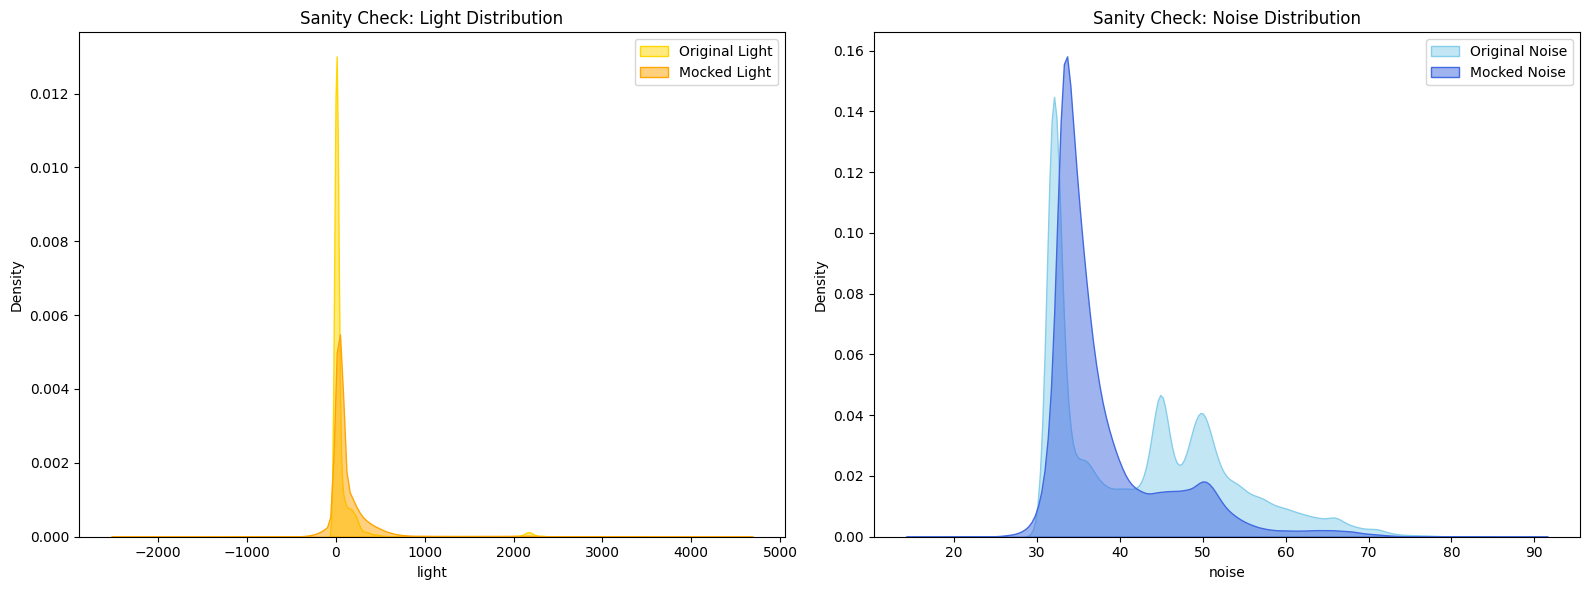

In [28]:
# Plot the distribution to check the 'texture' of the mocked data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- PLOT 1: LIGHT DISTRIBUTION ---
sns.kdeplot(combined_df['light'].dropna(), ax=ax1, label='Original Light', fill=True, alpha=0.5, color='gold')
sns.kdeplot(final_df.loc[combined_df['light'].isna(), 'light'], ax=ax1, label='Mocked Light', fill=True, alpha=0.5, color='orange')
ax1.set_title('Sanity Check: Light Distribution')
ax1.legend()

# --- PLOT 2: NOISE DISTRIBUTION ---
sns.kdeplot(combined_df['noise'].dropna(), ax=ax2, label='Original Noise', fill=True, alpha=0.5, color='skyblue')
sns.kdeplot(final_df.loc[combined_df['noise'].isna(), 'noise'], ax=ax2, label='Mocked Noise', fill=True, alpha=0.5, color='royalblue')
ax2.set_title('Sanity Check: Noise Distribution')
ax2.legend()

plt.tight_layout()
plt.show()